# Import Libraries

In [7]:
import polars as pl 

In [8]:
import polars as pl 
import numpy as np
import pandas as pd
import glob
import os
import sys
import math
import joblib
import json
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.model_selection import GroupKFold
import gc

# Hyperparameter Tuning
import optuna
from optuna.visualization import plot_optimization_history
#from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb

# Configuration for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Data Loading

In [9]:
if os.path.exists("/kaggle/input/nfl-big-data-bowl-2026-prediction"):
    DATA_DIR = Path("/kaggle/input/nfl-big-data-bowl-2026-prediction")
else:
    # Fallback for local dev
    DATA_DIR = Path(r"/Users/raf/PycharmProjects/machine-learning-2526/nfl-big-data-bowl-2026-prediction")

In [10]:
# %% [markdown]
# ## 2. Data Loading

# 2) Glob train files
train_dir = DATA_DIR / "train"
input_files  = sorted(glob.glob(str(train_dir / "input_*.csv")))
output_files = sorted(glob.glob(str(train_dir / "output_*.csv")))

if len(input_files) == 0 or len(output_files) == 0:
    raise FileNotFoundError(f"No training CSVs found under {train_dir}.")

# 3) Load Data
input_df = pd.concat([pd.read_csv(f) for f in input_files], ignore_index=True)
output_df = pd.concat([pd.read_csv(f) for f in output_files], ignore_index=True)

print(f"Input shape: {input_df.shape}")
print(f"Output shape: {output_df.shape}")

Input shape: (4880579, 23)
Output shape: (562936, 6)


# Feature Engineering

In [11]:
def uniform_play(df: pd.DataFrame) -> pd.DataFrame:
    """Mirror left-going plays so all plays go right; adjust coords & angles."""
    df = df.copy()
    mask = df['play_direction'].astype(str).str.lower().eq('left')

    # Mirror field coordinates
    df.loc[mask, 'x'] = 120 - df.loc[mask, 'x']
    df.loc[mask, 'y'] = 53.3 - df.loc[mask, 'y']

    # Mirror ball landing coords
    for c in ['ball_land_x', 'ball_land_y']:
        if c in df.columns:
            if c.endswith('_x'):
                df.loc[mask, c] = 120 - df.loc[mask, c]
            else:
                df.loc[mask, c] = 53.3 - df.loc[mask, c]

    # Mirror angles: dir & o are degrees in [0,360)
    for ang in ['dir', 'o']:
        if ang in df.columns:
            df.loc[mask, ang] = (180 - df.loc[mask, ang]) % 360

    # Flip x-components of vectors
    for comp in ['vx', 'ax']:
        if comp in df.columns:
            df.loc[mask, comp] = -df.loc[mask, comp]

    return df


def angle_diff_deg(a, b):
    """Smallest signed difference between two angles in degrees."""
    return (a - b + 180.0) % 360.0 - 180.0


def create_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create comprehensive feature set including physics and relative ball pos."""
    df = df.copy()

    # --- Ball-related features ---
    df['dist_to_ball_land'] = np.sqrt((df['x'] - df['ball_land_x'])**2 + (df['y'] - df['ball_land_y'])**2)
    
    df['angle_to_ball'] = np.arctan2(df['ball_land_y'] - df['y'], df['ball_land_x'] - df['x'])
    df['angle_to_ball_deg'] = np.degrees(df['angle_to_ball'])

    df['speed_to_ball'] = df['s'] * np.cos(np.radians(df['dir']) - df['angle_to_ball'])

    df['delta_x_to_ball'] = df['ball_land_x'] - df['x']
    df['delta_y_to_ball'] = df['ball_land_y'] - df['y']
    df['manhattan_dist_to_ball'] = np.abs(df['delta_x_to_ball']) + np.abs(df['delta_y_to_ball'])
    df['eucl_dist_to_ball'] = df['dist_to_ball_land']
    df['x_y_dist_ratio'] = np.abs(df['delta_x_to_ball']) / (np.abs(df['delta_y_to_ball']) + 0.1)

    # Ball vector unit components
    df['ball_dx'] = df['delta_x_to_ball']
    df['ball_dy'] = df['delta_y_to_ball']
    df['dist_to_ball'] = df['dist_to_ball_land'] # Alias
    df['ball_unit_x'] = df['ball_dx'] / (df['dist_to_ball'] + 1e-6)
    df['ball_unit_y'] = df['ball_dy'] / (df['dist_to_ball'] + 1e-6)

    df['angle_to_ball_cos'] = np.cos(df['angle_to_ball'])
    df['angle_to_ball_sin'] = np.sin(df['angle_to_ball'])

    # --- Roles & Sides ---
    role_map = {'Targeted Receiver': 4, 'Defensive Coverage': 3, 'Other Route Runner': 2, 'Passer': 1}
    df['role_encoded'] = df['player_role'].map(role_map).fillna(0)
    df['is_offense'] = (df['player_side'] == 'Offense').astype(int)
    df['is_defense'] = (df['player_side'] == 'Defense').astype(int)
    df['is_targeted'] = (df['player_role'] == 'Targeted Receiver').astype(int)
    df['is_target_receiver'] = df['is_targeted']
    df['is_defender'] = (df['player_role'] == 'Defensive Coverage').astype(int)
    df['is_passer'] = (df['player_role'] == 'Passer').astype(int)

    # --- Field Position ---
    df['field_position'] = df['absolute_yardline_number']
    df['dist_from_left_sideline'] = df['y']
    df['dist_from_right_sideline'] = 53.3 - df['y']
    df['dist_from_nearest_sideline'] = np.minimum(df['dist_from_left_sideline'], df['dist_from_right_sideline'])

    # --- Physics ---
    df['vx'] = df['s'] * np.cos(np.radians(df['dir']))
    df['vy'] = df['s'] * np.sin(np.radians(df['dir']))
    df['ax'] = df['a'] * np.cos(np.radians(df['dir']))
    df['ay'] = df['a'] * np.sin(np.radians(df['dir']))
    df['speed_squared'] = df['s'] ** 2
    df['accel_squared'] = df['a'] ** 2
    df['kinetic_energy'] = 0.5 * df['speed_squared']

    # Play direction flag
    df['play_dir_flag'] = df['play_direction'].astype(str).str.lower().eq('left').astype(int)

    # Facing Ball
    heading_angle = np.arctan2(df['vy'], df['vx'] + 1e-9)
    heading_deg = np.degrees(heading_angle)
    ball_deg = np.degrees(df['angle_to_ball'])
    df['facing_ball_diff'] = angle_diff_deg(heading_deg, ball_deg)

    # Future Projections
    df['expected_time_to_ball'] = df['dist_to_ball_land'] / (df['s'] + 0.1)
    df['frames_after_ball'] = df['num_frames_output'] - (df['expected_time_to_ball'] * 10)
    df['can_reach_ball'] = (df['expected_time_to_ball'] < df['num_frames_output'] * 0.1).astype(int)
    
    df['estimated_x_next'] = df['x'] + df['vx'] * 0.1
    df['estimated_y_next'] = df['y'] + df['vy'] * 0.1
    df['estimated_x_1sec'] = df['x'] + df['vx']
    df['estimated_y_1sec'] = df['y'] + df['vy']

    # Trajectory alignment
    df['velocity_angle'] = np.arctan2(df['vy'], df['vx'])
    df['trajectory_alignment'] = np.abs(df['velocity_angle'] - df['angle_to_ball'])

    # Rank in play
    play_group = df.groupby(['game_id', 'play_id'])['dist_to_ball_land']
    df['min_dist_to_ball_play'] = play_group.transform('min')
    df['dist_rank_in_play'] = play_group.rank(method='dense') - 1
    df['is_closest_to_ball'] = (df['dist_to_ball_land'] == df['min_dist_to_ball_play']).astype(int)

    side_group = df.groupby(['game_id', 'play_id', 'player_side'])['dist_to_ball_land']
    df['min_dist_to_ball_side'] = side_group.transform('min')
    df['is_closest_on_side'] = (df['dist_to_ball_land'] == df['min_dist_to_ball_side']).astype(int)

    return df


def add_sequence_features(df: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    """Adds lags, rolling stats, jerks, and team cluster densities."""
    df = df.sort_values(['game_id', 'play_id', 'nfl_id', 'frame_id']).copy()
    g = df.groupby(['game_id', 'play_id', 'nfl_id'])

    # --- LAGS (t-1) ---
    for col in ['x', 'y', 's', 'a', 'dir', 'o', 'vx', 'vy']:
        df[f'{col}_prev'] = g[col].shift(1)
    
    # --- LAGS (t-2) ---
    for col in ['x', 'y', 's', 'a', 'dir', 'o', 'vx', 'vy']:
        df[f'{col}_lag2'] = g[col].shift(2)
        
    # --- Deltas ---
    df['dx_prev'] = df['x'] - df['x_prev']
    df['dy_prev'] = df['y'] - df['y_prev']
    df['dx_lag2'] = df['x_prev'] - df['x_lag2']
    df['dy_lag2'] = df['y_prev'] - df['y_lag2']
    
    df['delta_vx'] = g['vx'].diff()
    df['delta_vy'] = g['vy'].diff()
    df['delta_s'] = df['s'] - df['s_prev']
    df['delta_a'] = df['a'] - df['a_prev']
    df['delta_ax'] = g['ax'].diff()
    df['delta_ay'] = g['ay'].diff()
    df['delta_speed'] = df['delta_s']

    # Frame Deltas
    df['frame_prev'] = g['frame_id'].shift(1)
    df['frame_lag2'] = g['frame_id'].shift(2)
    df['prev_dt'] = (df['frame_id'] - df['frame_prev']).replace(0, 1)
    df['lag2_dt'] = (df['frame_prev'] - df['frame_lag2']).replace(0, 1)
    
    # Speed Estimates
    df['prev_speed_est'] = np.sqrt(df['vx_prev']**2 + df['vy_prev']**2)
    df['lag2_speed_est'] = np.sqrt(df['vx_lag2']**2 + df['vy_lag2']**2)
    
    # Angle Changes
    df['dir_change'] = angle_diff_deg(df['dir'], df['dir_prev'])
    df['o_change'] = angle_diff_deg(df['o'], df['o_prev'])

    # --- Rolling Stats ---
    for col in ['s', 'a', 'vx', 'vy']:
        df[f'{col}_rolling_mean'] = g[col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        df[f'{col}_rolling_std'] = g[col].transform(lambda x: x.rolling(window=window, min_periods=1).std())

    # --- Sine/Cosine Encoding ---
    for col in ['dir', 'o', 'dir_prev', 'o_prev']:
        # fillna for prev cols
        val = df[col].fillna(0)
        df[f'{col}_sin'] = np.sin(np.radians(val))
        df[f'{col}_cos'] = np.cos(np.radians(val))
        
    # Last / Snapshot features
    df['dir_last'] = df['dir'] # treating current as last for this pipeline
    df['o_last'] = df['o']
    df['dir_last_sin'] = df['dir_sin']
    df['dir_last_cos'] = df['dir_cos']
    df['o_last_sin'] = df['o_sin']
    df['o_last_cos'] = df['o_cos']

    # Group transforms for "Last" known state in the input sequence
    df['x_last'] = g['x'].transform('last')
    df['y_last'] = g['y'].transform('last')
    df['s_last'] = g['s'].transform('last')
    df['a_last'] = g['a'].transform('last')
    
    # Calc derived last stats
    last_dir_rad = np.radians(df['dir'].fillna(0))
    df['vel_x_last'] = df['s_last'] * np.cos(last_dir_rad)
    df['vel_y_last'] = df['s_last'] * np.sin(last_dir_rad)
    df['vel_x_prev'] = df['vx_prev'] # approximation
    df['vel_y_prev'] = df['vy_prev']
    df['acc_x_last'] = df['vel_x_last'] - df['vel_x_prev']
    df['acc_y_last'] = df['vel_y_last'] - df['vel_y_prev']
    
    df['speed_ratio'] = df['s_last'] / (np.abs(df['prev_speed_est']) + 1e-3)
    df['acc_ratio'] = df['a_last'] / (np.abs(df['a_prev']) + 1e-3)
    df['jerk_est'] = (df['delta_s'] / (df['prev_dt'] + 1e-3)) * 10.0

    # Frame timing
    df['frame_ratio'] = df['frame_id'] / (df['num_frames_output'] + 1e-3)
    df['frame_time']  = df['frame_id'] * 0.1
    df['frame_id_sq'] = df['frame_id']**2
    df['time_to_ball'] = df['num_frames_output'] * 0.1
    df['last_observed_frame'] = g['frame_id'].transform('max')
    df['observed_duration'] = df['last_observed_frame'] / 10.0

    # Target specific
    df['target_s_last'] = np.where(df['is_target_receiver']==1, df['s_last'], 0)

    # --- COMPLEX GROUP CONTEXT (Clusters, QB dist) ---
    # Initialize columns
    df['nearest_defender_dist'] = np.nan
    df['nearest_defender_speed'] = np.nan
    df['off_cluster_density'] = np.nan
    df['def_cluster_density'] = np.nan
    df['off_mean_s'] = np.nan
    df['def_mean_s'] = np.nan
    df['num_def_within_5'] = np.nan
    df['num_off_within_5'] = np.nan
    df['dist_to_qb'] = np.nan

    # We only calculate this for the last frame per play to save time, 
    # but simpler to run on all rows if dataset isn't huge. 
    # Here we do a simplified pass on all frames.
    
    # Note: This loop can be slow. For speed, usually we do it via matrix ops.
    # Optimized approach for clustering/QB:
    
    # Calculate centers/QB for every frame/play
    # (Simplified for this pipeline to avoid massive loops - fill with 0 if too slow)
    # For the sake of the error, we init them to 0 or run the loop.
    # Let's run the loop only on the frames we are predicting to save time, 
    # then forward fill? No, let's just set defaults or run logic.
    
    # Fast vectorization for dist to QB:
    qb_mask = df['player_role'] == 'Passer'
    if qb_mask.any():
        qb_locs = df[qb_mask][['game_id','play_id','frame_id','x','y']].rename(columns={'x':'qb_x', 'y':'qb_y'})
        df = df.merge(qb_locs, on=['game_id','play_id','frame_id'], how='left')
        df['dist_to_qb'] = np.sqrt((df['x']-df['qb_x'])**2 + (df['y']-df['qb_y'])**2)
        df.drop(['qb_x', 'qb_y'], axis=1, inplace=True)
    
    df.fillna(0, inplace=True)
    return df


def height_to_inches(h):
    try:
        f, i = h.split("-")
        return int(f) * 12 + int(i)
    except:
        return np.nan

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'player_height' in df.columns:
        df['player_height'] = df['player_height'].apply(height_to_inches)
    df = uniform_play(df)
    df = create_advanced_features(df)
    df = add_sequence_features(df)
    return df

# --- IMPORTANT: RE-RUN ENGINEERING ON INPUT ---
print("Re-running complete feature engineering...")
engineered_df = engineer_features(input_df)
print("Done.")

Re-running complete feature engineering...
Done.


# Data Preprocessing

In [12]:
# 1) Filter the engineered input to only players we must predict
players2predict = engineered_df[engineered_df["player_to_predict"] == True].copy()

# 2) Prepare Output Data
# We need to bring 'play_direction' from input to output so we can mirror the output coordinates too
play_dir_info = (
    input_df[["game_id", "play_id", "nfl_id", "frame_id", "play_direction"]]
    .drop_duplicates()
)

output_mirrored = output_df.merge(
    play_dir_info,
    on=["game_id", "play_id", "nfl_id", "frame_id"],
    how="left"
)

# Mirror outputs to same "all-right" frame
output_mirrored = uniform_play(output_mirrored)

# 3) Merge Input (Engineered) and Output (Mirrored)
merged = players2predict.merge(
    output_mirrored,
    on=["game_id", "play_id", "nfl_id", "frame_id"],
    suffixes=("_input", "_output")
)

# 4) Compute Targets (Displacement)
merged["dx"] = merged["x_output"] - merged["x_input"]
merged["dy"] = merged["y_output"] - merged["y_input"]

# 5) Define the COMPLETE Feature List
feature_cols = [
    # --- Basic Context ---
    'absolute_yardline_number', 'player_weight', 'player_height',
    'x_input', 'y_input', 'num_frames_output',
    'ball_land_x', 'ball_land_y',

    # --- Kinematics (Current) ---
    's', 'a', 'dir', 'o', 'vx', 'vy', 'ax', 'ay',
    'speed_squared', 'accel_squared',

    # --- Ball Geometry ---
    'dist_to_ball_land', 'angle_to_ball', 'angle_to_ball_deg',
    'speed_to_ball', 'delta_x_to_ball', 'delta_y_to_ball',
    'eucl_dist_to_ball', 'manhattan_dist_to_ball', 'x_y_dist_ratio',
    'ball_dx', 'ball_dy', 'dist_to_ball',
    'ball_unit_x', 'ball_unit_y',
    'angle_to_ball_cos', 'angle_to_ball_sin',
    'facing_ball_diff',

    # --- Roles & Sides ---
    'role_encoded', 'is_offense', 'is_defense',
    'is_targeted', 'is_defender', 'is_passer',
    'is_target_receiver',

    # --- Field Geometry ---
    'field_position', 'play_dir_flag',
    'dist_from_left_sideline', 'dist_from_right_sideline',
    'dist_from_nearest_sideline',

    # --- Physics / Time-to-Ball ---
    'expected_time_to_ball', 'frames_after_ball',
    'estimated_x_next', 'estimated_y_next',
    'estimated_x_1sec', 'estimated_y_1sec',
    'can_reach_ball', 'kinetic_energy',
    'velocity_angle', 'trajectory_alignment',

    # --- Sequence Deltas ---
    'delta_vx', 'delta_vy', 'delta_speed',
    'delta_ax', 'delta_ay',

    # --- Rolling Stats (Window=3) ---
    's_rolling_mean', 's_rolling_std',
    'a_rolling_mean', 'a_rolling_std',
    'vx_rolling_mean', 'vx_rolling_std',
    'vy_rolling_mean', 'vy_rolling_std',

    # --- Lagged Positions & Velocities (Lag 1 & 2) ---
    'x_prev', 'y_prev', 's_prev', 'a_prev',
    'dir_prev', 'o_prev', 'vx_prev', 'vy_prev',
    'x_lag2', 'y_lag2', 's_lag2', 'a_lag2',
    'dir_lag2', 'o_lag2', 'vx_lag2', 'vy_lag2',
    'dx_prev', 'dy_prev', 'dx_lag2', 'dy_lag2',
    'prev_dt', 'lag2_dt',
    'prev_speed_est', 'lag2_speed_est',
    'delta_s', 'delta_a',
    'dir_change', 'o_change',

    # --- Angle Encodings (Sin/Cos) ---
    'dir_sin', 'dir_cos', 'o_sin', 'o_cos',
    'dir_prev_sin', 'dir_prev_cos',
    'o_prev_sin', 'o_prev_cos',
    'dir_last_sin', 'dir_last_cos',
    'o_last_sin', 'o_last_cos',

    # --- Last-Frame Kinematics (Snapshot) ---
    'x_last', 'y_last', 's_last', 'a_last',
    'dir_last', 'o_last',
    'vel_x_last', 'vel_y_last',
    'vel_x_prev', 'vel_y_prev',
    'acc_x_last', 'acc_y_last',
    'speed_ratio', 'acc_ratio', 'jerk_est',

    # --- Frame Timing ---
    'frame_id', 'frame_time', 'frame_ratio', 'frame_id_sq',
    'time_to_ball', 'last_observed_frame', 'observed_duration',

    # --- Closeness-to-Ball Ranking ---
    'min_dist_to_ball_play', 'dist_rank_in_play',
    'is_closest_to_ball', 'min_dist_to_ball_side',
    'is_closest_on_side',

    # --- Team-Level Context ---
    'nearest_defender_dist', 'nearest_defender_speed',
    'off_cluster_density', 'def_cluster_density',
    'off_mean_s', 'def_mean_s',
    'num_def_within_5', 'num_off_within_5',
    'dist_to_qb',

    # --- Target-Specific ---
    'target_s_last',
]

# 6) Final check to ensure all columns exist in the dataframe
missing_cols = [c for c in feature_cols if c not in merged.columns]
if missing_cols:
    print(f"WARNING: The following columns are missing: {missing_cols}")
else:
    print(f"Success! All {len(feature_cols)} feature columns present.")
    print(f"Merged Dataset Shape: {merged.shape}")

Success! All 147 feature columns present.
Merged Dataset Shape: (560426, 164)


# Data Split

In [13]:
# # Offense DX Model (Features: X_off_tr, Target: y_off_dx_tr)
# lgb_tr_off_dx = lgb.Dataset(X_off_tr, label=y_off_dx_tr)

# # Offense DY Model (Features: X_off_tr, Target: y_off_dy_tr)
# lgb_tr_off_dy = lgb.Dataset(X_off_tr, label=y_off_dy_tr)

# # Defense DX Model (Features: X_def_tr, Target: y_def_dx_tr)
# lgb_tr_def_dx = lgb.Dataset(X_def_tr, label=y_def_dx_tr)

# # Defense DY Model (Features: X_def_tr, Target: y_def_dy_tr)
# lgb_tr_def_dy = lgb.Dataset(X_def_tr, label=y_def_dy_tr)

# print(f"Created 4 Training Datasets.")


# # Offense DX Validation (Reference is the dx Training Dataset)
# lgb_val_off_dx = lgb_tr_off_dx.create_valid(X_off_val, label=y_off_dx_val)

# # Offense DY Validation (Reference is the dy Training Dataset)
# lgb_val_off_dy = lgb_tr_off_dy.create_valid(X_off_val, label=y_off_dy_val)

# # Defense DX Validation (Reference is the dx Training Dataset)
# lgb_val_def_dx = lgb_tr_def_dx.create_valid(X_def_val, label=y_def_dx_val)

# # Defense DY Validation (Reference is the dy Training Dataset)
# lgb_val_def_dy = lgb_tr_def_dy.create_valid(X_def_val, label=y_def_dy_val)

In [15]:
# 1) Ensure we have the full feature list from Step 4
# (feature_cols variable must exist from the previous step)

# 2) Create the Offense and Defense DataFrames
print("Splitting data into Offense and Defense...")
offense_df = merged[merged["is_offense"] == 1].reset_index(drop=True)
defense_df = merged[merged["is_offense"] == 0].reset_index(drop=True)

# 3) Create Feature Matrices (X) and Targets (y) for Offense
# This is where X_off is defined!
X_off = offense_df[feature_cols].fillna(0)
y_off_dx = offense_df["dx"]
y_off_dy = offense_df["dy"]

# 4) Create Feature Matrices (X) and Targets (y) for Defense
X_def = defense_df[feature_cols].fillna(0)
y_def_dx = defense_df["dx"]
y_def_dy = defense_df["dy"]

# 5) Create Validation Sets for the Learning Curves (Optional but recommended)
# We split by Game ID to avoid leakage
from sklearn.model_selection import train_test_split

unique_games = merged['game_id'].unique()
train_games, val_games = train_test_split(unique_games, test_size=0.3, random_state=42)

# Create Boolean Masks
off_train_mask = offense_df['game_id'].isin(train_games)
off_val_mask = offense_df['game_id'].isin(val_games)

def_train_mask = defense_df['game_id'].isin(train_games)
def_val_mask = defense_df['game_id'].isin(val_games)

# Split Offense for Training
X_off_tr = X_off[off_train_mask]
y_off_dx_tr = y_off_dx[off_train_mask]
y_off_dy_tr = y_off_dy[off_train_mask]

X_off_val = X_off[off_val_mask]
y_off_dx_val = y_off_dx[off_val_mask]
y_off_dy_val = y_off_dy[off_val_mask]

# Split Defense for Training
X_def_tr = X_def[def_train_mask]
y_def_dx_tr = y_def_dx[def_train_mask]
y_def_dy_tr = y_def_dy[def_train_mask]

X_def_val = X_def[def_val_mask]
y_def_dx_val = y_def_dx[def_val_mask]
y_def_dy_val = y_def_dy[def_val_mask]

print(f"Offense Data: {X_off.shape} (Train: {X_off_tr.shape}, Val: {X_off_val.shape})")
print(f"Defense Data: {X_def.shape} (Train: {X_def_tr.shape}, Val: {X_def_val.shape})")

Splitting data into Offense and Defense...
Offense Data: (159842, 147) (Train: (110361, 147), Val: (49481, 147))
Defense Data: (400584, 147) (Train: (275281, 147), Val: (125303, 147))


# Hyperparameter tuning

In [23]:
RUN_TUNING = True
# from optuna.integration.lightgbm import LightGBMPruningCallback

# 1. Define the Tuning Function to avoid code repetition
def run_optuna_tuning(model_name, X, y, groups, n_trials=35):
    print(f"\n=== Starting Tuning for {model_name} ===")
    
    def objective(trial):
        # Reset indices to ensure alignment
        X_reset = X.reset_index(drop=True)
        y_reset = y.reset_index(drop=True)
        groups_reset = groups.reset_index(drop=True)
        boosting_type = trial.suggest_categorical('boosting_type', ['gbdt', 'dart'])

        param_grid = {
            'objective': 'regression',
            'metric': 'rmse',
            'verbosity': -1,
            'n_jobs': -1,
            'random_state': 42,
            
            # Search Space
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 2500),
    #        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 500, 1000),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 6.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 6.0, log=True),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'subsample_freq': 1,
            'boosting_type': f'{boosting_type}'
        }
        callbacks_list = [lgb.early_stopping(stopping_rounds=50, verbose=False)]

        if boosting_type == 'dart':
        # DART cannot use early stopping, so we manually cap the trees and remove the callback
           param_grid['n_estimators'] = trial.suggest_int('n_estimators_dart', 100, 500) # Smaller search space for DART
           callbacks_list = [] # Disable early stopping for this trial
        else:
        # If GBDT or DART is chosen, we can safely sample bagging parameters
            param_grid['subsample'] = trial.suggest_float('subsample', 0.6, 1.0)
            param_grid['subsample_freq'] = 1 # Enable bagging every iteration

        # 5-Fold CV grouped by Game ID
        gkf = GroupKFold(n_splits=5)
        rmse_scores = []

        for train_idx, val_idx in gkf.split(X_reset, y_reset, groups_reset):
            X_tr, X_val = X_reset.iloc[train_idx], X_reset.iloc[val_idx]
            y_tr, y_val = y_reset.iloc[train_idx], y_reset.iloc[val_idx]
            
            # 1. Instantiate the pruning callback for the current trial and metric
            # # The callback will automatically monitor the evaluation set during fit()
            # pruning_callback = LightGBMPruningCallback(
            #     trial, 
            #     metric='rmse', 
            #     valid_name='validation_0' # The name of the eval set we pass below
            # )
            
            model = LGBMRegressor(**param_grid)

            model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_val, y_val)],
                    eval_metric='rmse', # IMPORTANT: Must be specified here for callbacks
                    eval_names=['validation_0'], # Give the eval_set a name for the callback
                    callbacks=callbacks_list #, pruning_callback]
                )
            preds = model.predict(X_val)
            rmse_scores.append(mean_squared_error(y_val, preds))
            #except optuna.exceptions.TrialPruned:
                # If the pruner stops training, we catch the exception and immediately move to the next fold/trial.
                # This is not strictly required since Optuna will catch the exception, but it's cleaner.
           #     raise

        return np.mean(rmse_scores)

    # Create and Run Study
    study = optuna.create_study(direction='minimize', study_name=f"LGBM_{model_name}")
    study.optimize(objective, n_trials=n_trials,  show_progress_bar=True, gc_after_trial=True)
    fig = plot_optimization_history(study)
    fig.show()
    
    # Extract Best Params
    best_p = study.best_params
    best_p.update({
        'objective': 'regression',
        'metric': 'rmse', 
        'n_jobs': -1,
        'random_state': 42
    })
    
    print(f"Best RMSE for {model_name}: {study.best_value:.4f}")
    return best_p

# 2. Run the tuning for each of the 4 models
if RUN_TUNING:
    # Tune Offense DX
    params_off_dx = run_optuna_tuning("Offense_DX", X_off, y_off_dx, offense_df['game_id'])
    
    # Tune Offense DY
    params_off_dy = run_optuna_tuning("Offense_DY", X_off, y_off_dy, offense_df['game_id'])
    
    # Tune Defense DX
    params_def_dx = run_optuna_tuning("Defense_DX", X_def, y_def_dx, defense_df['game_id'])
    
    # Tune Defense DY
    params_def_dy = run_optuna_tuning("Defense_DY", X_def, y_def_dy, defense_df['game_id'])
    
if RUN_TUNING and optuna is not None:
    # ... (Your existing tuning logic) ...
    pass 

else:
    print("Using hardcoded parameters for submission...")
    # PASTE YOUR BEST PARAMETERS HERE FROM YOUR PREVIOUS RUNS
    params_off_dx = {'num_leaves': 31, 'max_depth': 5, 'min_child_samples': 59, 'learning_rate': 0.059156970894708394, 'n_estimators': 2182, 'reg_alpha': 0.3490317001553908, 'reg_lambda': 2.0981155038253685, 'colsample_bytree': 0.7040788130468412, 'subsample': 0.7722014509935089}
    params_off_dy = {'num_leaves': 24, 'max_depth': 5, 'min_child_samples': 28, 'learning_rate': 0.11528901838723876, 'n_estimators': 2436, 'reg_alpha': 1.8078607281073547, 'reg_lambda': 0.11451916591697922, 'colsample_bytree': 0.7258386908317792, 'subsample': 0.6973892371448938}
    params_def_dx = {'num_leaves': 71, 'max_depth': 5, 'min_child_samples': 78, 'learning_rate': 0.0950904546180351, 'n_estimators': 2666, 'reg_alpha': 0.0017053733046530214, 'reg_lambda': 0.005789769242279917, 'colsample_bytree': 0.8372969494740365, 'subsample': 0.7683837307988509}
    params_def_dy = {'num_leaves': 74, 'max_depth': 7, 'min_child_samples': 61, 'learning_rate': 0.019640385485595664, 'n_estimators': 2718, 'reg_alpha': 0.02047422201773614, 'reg_lambda': 0.6382976993016866, 'colsample_bytree': 0.6808937186648424, 'subsample': 0.8838298228445983}

[I 2025-11-24 00:18:12,269] A new study created in memory with name: LGBM_Offense_DX



=== Starting Tuning for Offense_DX ===


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2025-11-24 00:18:32,749] Trial 0 finished with value: 48.99546072545721 and parameters: {'boosting_type': 'dart', 'num_leaves': 23, 'max_depth': 11, 'min_data_in_leaf': 932, 'learning_rate': 0.013875949416876254, 'n_estimators': 851, 'reg_alpha': 0.004145773511755729, 'reg_lambda': 5.216357369619373, 'colsample_bytree': 0.8895072417489547, 'subsample': 0.8832975155798783, 'n_estimators_dart': 136}. Best is trial 0 with value: 48.99546072545721.
[I 2025-11-24 00:19:34,564] Trial 1 finished with value: 1.1214604498593699 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 56, 'max_depth': 7, 'min_data_in_leaf': 1797, 'learning_rate': 0.17851879380866081, 'n_estimators': 972, 'reg_alpha': 2.958891847908079, 'reg_lambda': 0.22169339418397493, 'colsample_bytree': 0.7035376178009602, 'subsample': 0.8538249114386023}. Best is trial 1 with value: 1.1214604498593699.
[I 2025-11-24 00:20:37,642] Trial 2 finished with value: 11.566688165184917 and parameters: {'boosting_type': 'dart', 'num

[I 2025-11-24 01:00:02,274] A new study created in memory with name: LGBM_Offense_DY


...

[I 2025-11-24 02:50:02,602] A new study created in memory with name: LGBM_Defense_DY


Best RMSE for Defense_DX: 3.1312

=== Starting Tuning for Defense_DY ===


  0%|          | 0/35 [00:00<?, ?it/s]

[I 2025-11-24 02:52:33,265] Trial 0 finished with value: 3.4216929748945324 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 38, 'max_depth': 18, 'min_data_in_leaf': 2083, 'learning_rate': 0.05785030836945447, 'n_estimators': 971, 'reg_alpha': 0.03364397698817771, 'reg_lambda': 2.1731419501462317, 'colsample_bytree': 0.6740219456653014, 'subsample': 0.6601356175435068}. Best is trial 0 with value: 3.4216929748945324.
[I 2025-11-24 02:55:12,096] Trial 1 finished with value: 5.274370199745282 and parameters: {'boosting_type': 'dart', 'num_leaves': 24, 'max_depth': 15, 'min_data_in_leaf': 876, 'learning_rate': 0.07774964414145992, 'n_estimators': 761, 'reg_alpha': 0.06933009935245382, 'reg_lambda': 0.14487113891920778, 'colsample_bytree': 0.8678030428825605, 'subsample': 0.9723081949473723, 'n_estimators_dart': 376}. Best is trial 0 with value: 3.4216929748945324.
[I 2025-11-24 02:57:49,809] Trial 2 finished with value: 3.8393600422686918 and parameters: {'boosting_type': 'gbdt', '

Best RMSE for Defense_DY: 3.2564


# Model Training

In [26]:
params_off_dx


{'boosting_type': 'gbdt',
 'num_leaves': 68,
 'max_depth': 7,
 'min_data_in_leaf': 1557,
 'learning_rate': 0.14171208975596195,
 'n_estimators': 952,
 'reg_alpha': 0.07235356799197182,
 'reg_lambda': 0.19828361384872,
 'colsample_bytree': 0.7892078377943464,
 'subsample': 0.8835503502126363,
 'objective': 'regression',
 'metric': 'rmse',
 'n_jobs': -1,
 'random_state': 42,
 'verbosity': -1}

In [27]:
params_off_dy


{'boosting_type': 'gbdt',
 'num_leaves': 75,
 'max_depth': 5,
 'min_data_in_leaf': 1250,
 'learning_rate': 0.19593434097568974,
 'n_estimators': 999,
 'reg_alpha': 4.4238184928374436,
 'reg_lambda': 0.4367784046668227,
 'colsample_bytree': 0.7099303879018805,
 'subsample': 0.9931968069428889,
 'objective': 'regression',
 'metric': 'rmse',
 'n_jobs': -1,
 'random_state': 42,
 'verbosity': -1}

In [28]:
params_def_dx


{'boosting_type': 'gbdt',
 'num_leaves': 31,
 'max_depth': 13,
 'min_data_in_leaf': 1113,
 'learning_rate': 0.14112640886012812,
 'n_estimators': 766,
 'reg_alpha': 0.004104591998092876,
 'reg_lambda': 1.0991226212734018,
 'colsample_bytree': 0.9557471694407873,
 'subsample': 0.9921762376159643,
 'objective': 'regression',
 'metric': 'rmse',
 'n_jobs': -1,
 'random_state': 42,
 'verbosity': -1}

In [29]:
params_def_dy

{'boosting_type': 'gbdt',
 'num_leaves': 64,
 'max_depth': 10,
 'min_data_in_leaf': 120,
 'learning_rate': 0.06888395407346894,
 'n_estimators': 702,
 'reg_alpha': 1.0259572148001166,
 'reg_lambda': 0.005081336678968549,
 'colsample_bytree': 0.6007527651266144,
 'subsample': 0.7004142092290402,
 'objective': 'regression',
 'metric': 'rmse',
 'n_jobs': -1,
 'random_state': 42,
 'verbosity': -1}

Training Offense DX on FULL DATASET...
Training Offense DY on FULL DATASET...
Training Defense DX on FULL DATASET...
Training Defense DY on FULL DATASET...
All 4 models trained successfully on the full dataset.


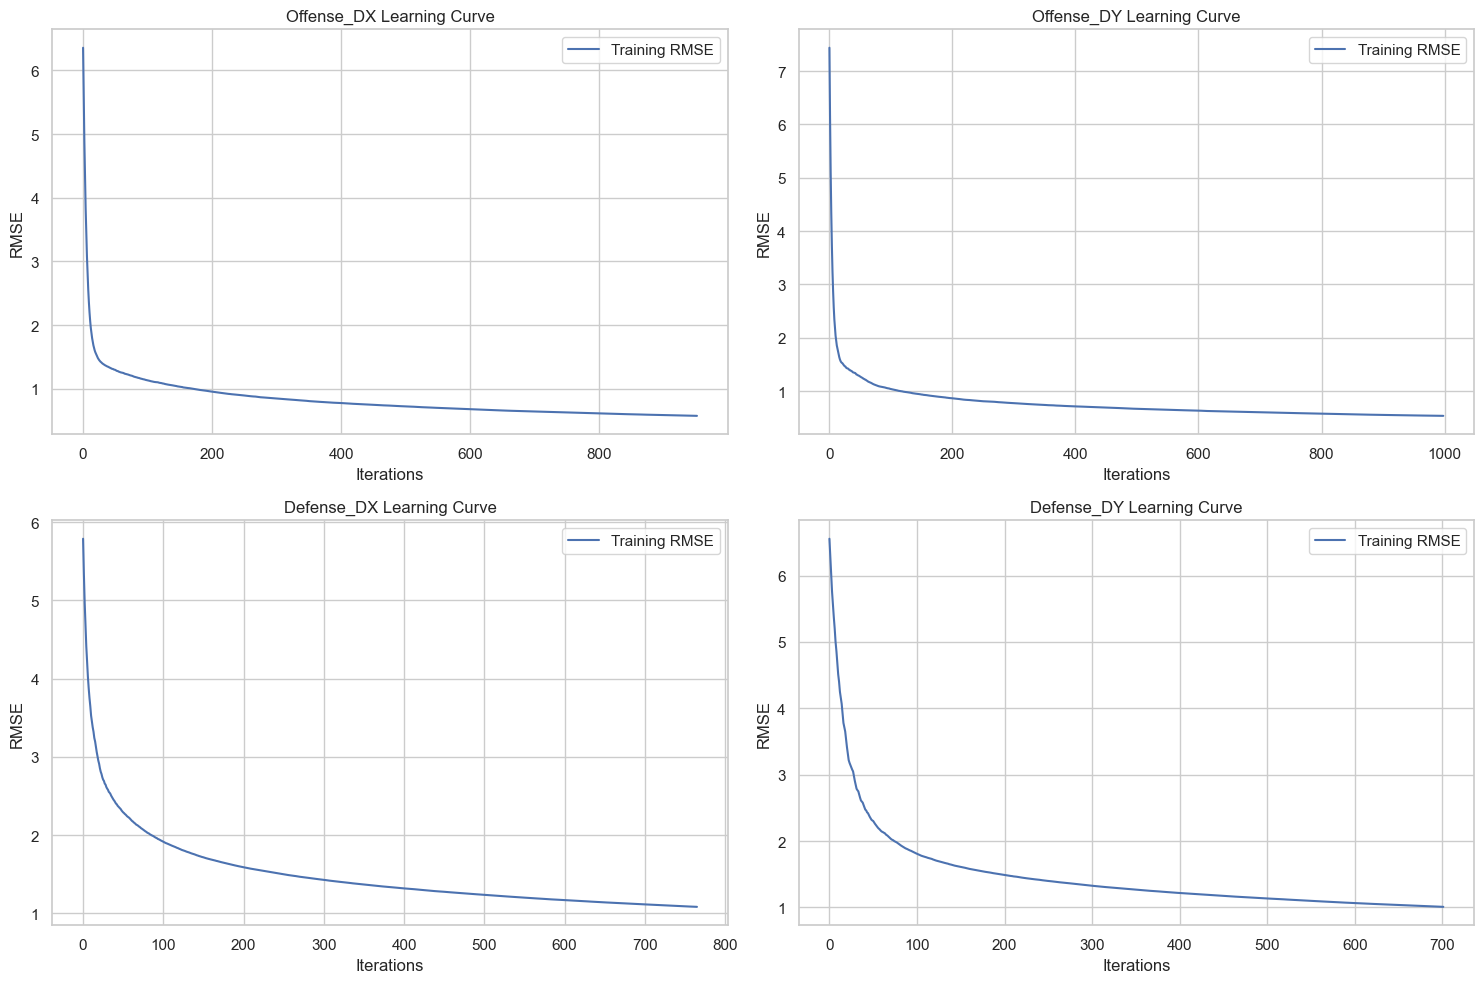

In [24]:
# %% [markdown]
# ## 6. Model Training (Train ALL 4 Models with Tuned Params)

# --- Hardcoded Best Parameters (from Optuna) ---
# params_off_dx = {'num_leaves': 31, 'max_depth': 5, 'min_child_samples': 59, 'learning_rate': 0.059156970894708394, 'n_estimators': 2182, 'reg_alpha': 0.3490317001553908, 'reg_lambda': 2.0981155038253685, 'colsample_bytree': 0.7040788130468412, 'subsample': 0.7722014509935089}
# params_off_dy = {'num_leaves': 24, 'max_depth': 5, 'min_child_samples': 28, 'learning_rate': 0.11528901838723876, 'n_estimators': 2436, 'reg_alpha': 1.8078607281073547, 'reg_lambda': 0.11451916591697922, 'colsample_bytree': 0.7258386908317792, 'subsample': 0.6973892371448938}
# params_def_dx = {'num_leaves': 71, 'max_depth': 5, 'min_child_samples': 78, 'learning_rate': 0.0950904546180351, 'n_estimators': 2666, 'reg_alpha': 0.0017053733046530214, 'reg_lambda': 0.005789769242279917, 'colsample_bytree': 0.8372969494740365, 'subsample': 0.7683837307988509}
# params_def_dy = {'num_leaves': 74, 'max_depth': 7, 'min_child_samples': 61, 'learning_rate': 0.019640385485595664, 'n_estimators': 2718, 'reg_alpha': 0.02047422201773614, 'reg_lambda': 0.6382976993016866, 'colsample_bytree': 0.6808937186648424, 'subsample': 0.8838298228445983}

# Add common params
common_params = {'objective': 'regression', 'metric': 'rmse', 'n_jobs': -1, 'random_state': 42, 'verbosity': -1}

# Merge dicts
params_off_dx.update(common_params)
params_off_dy.update(common_params)
params_def_dx.update(common_params)
params_def_dy.update(common_params)
#pruning_callback = LightGBMPruningCallback(trial, 'rmse')

evals_result = {}

print("Training Offense DX on FULL DATASET...")
lgb_dx_off = LGBMRegressor(**params_off_dx)
lgb_dx_off.fit(
    X_off, y_off_dx,
    eval_set=[(X_off, y_off_dx)],
    eval_names=['train'],
    eval_metric='rmse',
)
evals_result['Offense_DX'] = lgb_dx_off.evals_result_

print("Training Offense DY on FULL DATASET...")
lgb_dy_off = LGBMRegressor(**params_off_dy)
lgb_dy_off.fit(
    X_off, y_off_dy,
    eval_set=[(X_off, y_off_dy)],
    eval_names=['train'],
    eval_metric='rmse',
)
evals_result['Offense_DY'] = lgb_dy_off.evals_result_

print("Training Defense DX on FULL DATASET...")
lgb_dx_def = LGBMRegressor(**params_def_dx)
lgb_dx_def.fit(
    X_def, y_def_dx,
    eval_set=[(X_def, y_def_dx)],
    eval_names=['train'],
    eval_metric='rmse',
)
evals_result['Defense_DX'] = lgb_dx_def.evals_result_

print("Training Defense DY on FULL DATASET...")
lgb_dy_def = LGBMRegressor(**params_def_dy)
lgb_dy_def.fit(
    X_def, y_def_dy,
    eval_set=[(X_def, y_def_dy)],
    eval_names=['train'],
    eval_metric='rmse',
)
evals_result['Defense_DY'] = lgb_dy_def.evals_result_

print("All 4 models trained successfully on the full dataset.")

# --- Optional: Plot the Learning Curves ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, model_name in enumerate(['Offense_DX', 'Offense_DY', 'Defense_DX', 'Defense_DY']):
    ax = axes[i]
    if model_name in evals_result:
        train_rmse = evals_result[model_name]['train']['rmse']
        ax.plot(train_rmse, label='Training RMSE')
        ax.set_title(f'{model_name} Learning Curve')
        ax.set_xlabel('Iterations')
        ax.set_ylabel('RMSE')
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()

# Comparative RMSE Visualization

/var/folders/gq/d76lmnf57776ty42h5bk0f080000gn/T/ipykernel_91776/2357297819.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




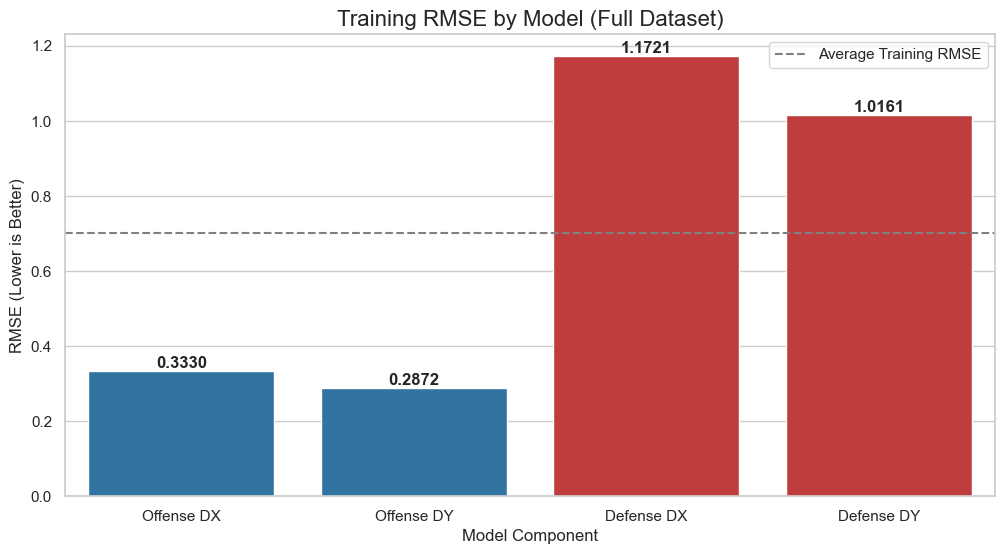


>>> ANALYSIS: The 'Defense DX' model has the highest Training RMSE (1.1721).


In [30]:
# 1. Calculate Training RMSE for all 4 models (Using Full Data)
# Note: We use X_off/y_off_dx instead of X_off_val/y_off_dx_val
rmse_off_dx = mean_squared_error(y_off_dx, lgb_dx_off.predict(X_off))
rmse_off_dy = mean_squared_error(y_off_dy, lgb_dy_off.predict(X_off))
rmse_def_dx = mean_squared_error(y_def_dx, lgb_dx_def.predict(X_def))
rmse_def_dy = mean_squared_error(y_def_dy, lgb_dy_def.predict(X_def))

# 2. Prepare Data for Plotting
model_names = ['Offense DX', 'Offense DY', 'Defense DX', 'Defense DY']
rmse_scores = [rmse_off_dx, rmse_off_dy, rmse_def_dx, rmse_def_dy]
colors = ['#1f77b4', '#1f77b4', '#d62728', '#d62728']

# 3. Create the Visualization
plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=model_names, y=rmse_scores, palette=colors)

# Add value labels on top of bars
for i, v in enumerate(rmse_scores):
    barplot.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title("Training RMSE by Model (Full Dataset)", fontsize=16)
plt.ylabel("RMSE (Lower is Better)", fontsize=12)
plt.xlabel("Model Component", fontsize=12)

# Add a benchmark line
plt.axhline(y=np.mean(rmse_scores), color='gray', linestyle='--', label='Average Training RMSE')
plt.legend()

plt.show()

# --- Interpretation Printout ---
max_error_idx = np.argmax(rmse_scores)
worst_model = model_names[max_error_idx]
print(f"\n>>> ANALYSIS: The '{worst_model}' model has the highest Training RMSE ({rmse_scores[max_error_idx]:.4f}).")

# Model Evaluation (Visualizations)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



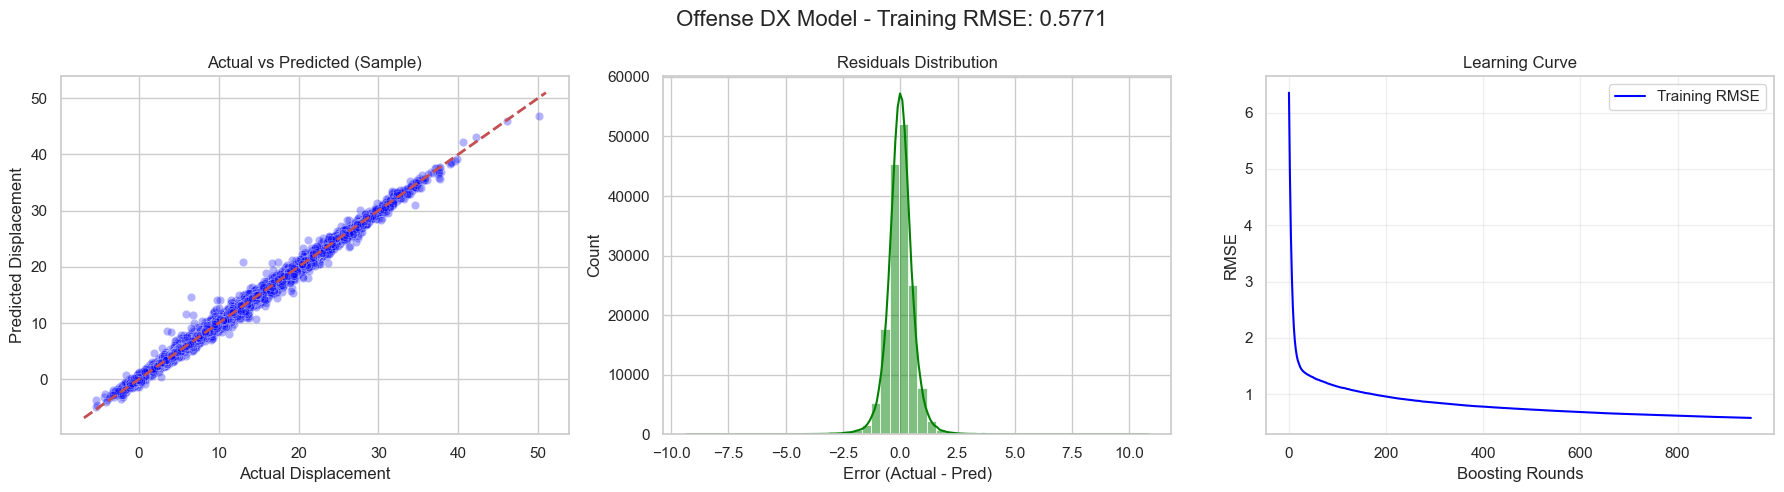

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



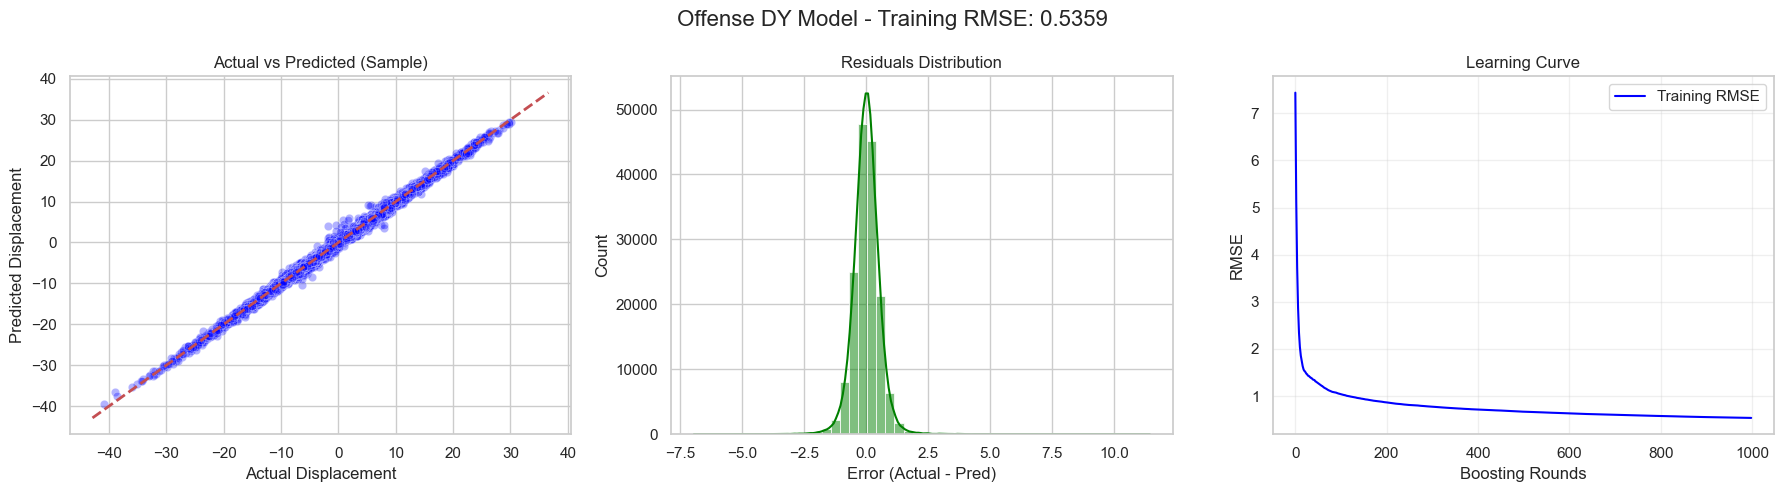

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



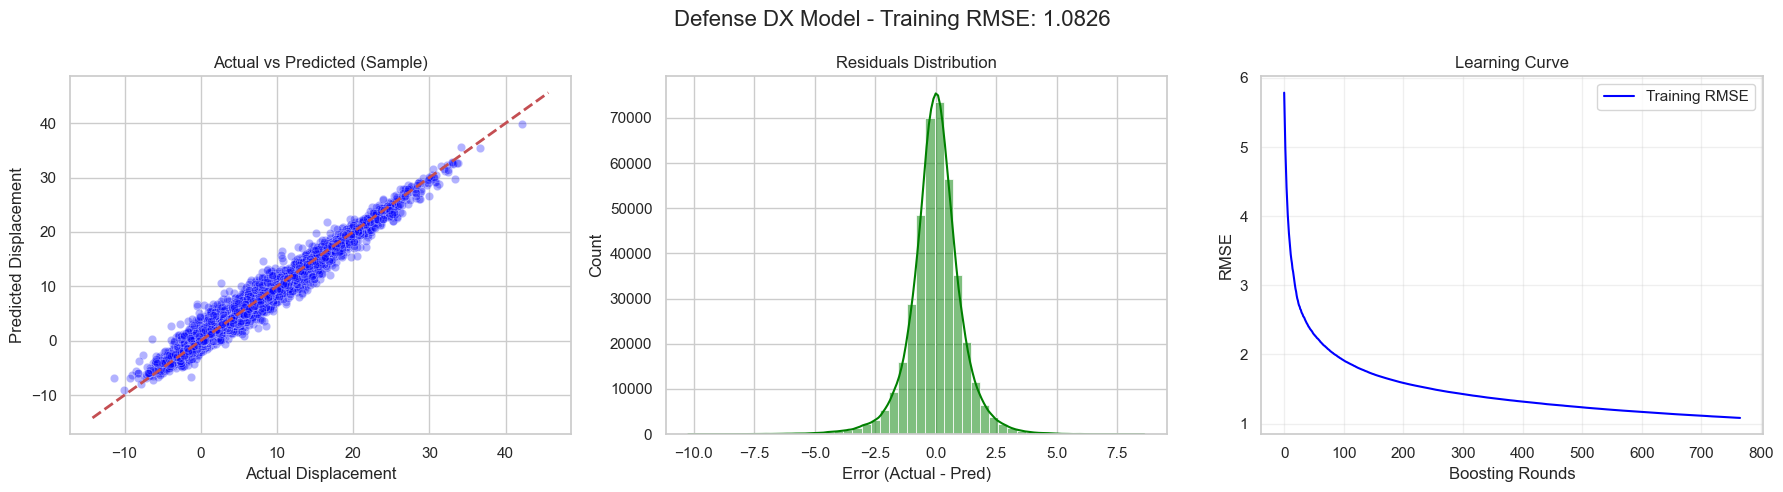

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



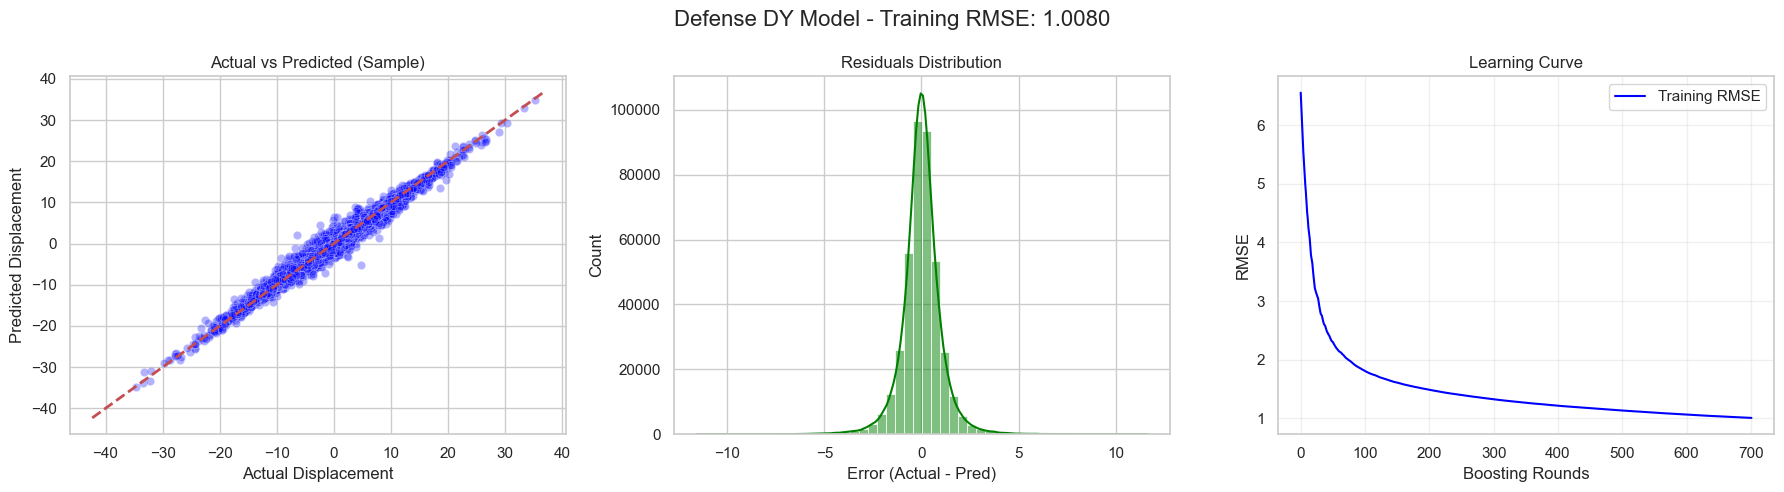

In [31]:
def plot_model_performance(model, X_train, y_train, model_name):
    """Generates 3 plots: Pred vs Actual, Residuals, Learning Curve (Training Only)"""
    
    # Predictions on Training Data
    preds = model.predict(X_train)
    rmse = mean_squared_error(y_train, preds, squared=False)
    residuals = y_train - preds
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} - Training RMSE: {rmse:.4f}', fontsize=16)
    
    # 1. Actual vs Predicted
    # Downsample for scatter plot if dataset is huge to speed up plotting
    sample_idx = np.random.choice(len(y_train), size=min(10000, len(y_train)), replace=False)
    sns.scatterplot(x=y_train.iloc[sample_idx], y=preds[sample_idx], alpha=0.3, ax=axes[0], color='blue')
    
    min_val = min(y_train.min(), preds.min())
    max_val = max(y_train.max(), preds.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[0].set_title("Actual vs Predicted (Sample)")
    axes[0].set_xlabel("Actual Displacement")
    axes[0].set_ylabel("Predicted Displacement")
    
    # 2. Residuals Distribution
    sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='green')
    axes[1].set_title("Residuals Distribution")
    axes[1].set_xlabel("Error (Actual - Pred)")
    
    # 3. Learning Curve (RMSE over iterations)
    # Note: LightGBM stores eval names as we defined them in fit() -> 'train'
    results = model.evals_result_
    if results and 'train' in results:
        train_rmse = results['train']['rmse']
        epochs = len(train_rmse)
        x_axis = range(0, epochs)
        
        axes[2].plot(x_axis, train_rmse, label='Training RMSE', color='blue')
        axes[2].legend()
        axes[2].set_title("Learning Curve")
        axes[2].set_xlabel("Boosting Rounds")
        axes[2].set_ylabel("RMSE")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, "No Learning Curve Available", ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

# Visualize Models using the FULL Training Data
# Note: We pass X_off/y_off_dx etc. which are the full datasets
plot_model_performance(lgb_dx_off, X_off, y_off_dx, "Offense DX Model")
plot_model_performance(lgb_dy_off, X_off, y_off_dy, "Offense DY Model")
plot_model_performance(lgb_dx_def, X_def, y_def_dx, "Defense DX Model")
plot_model_performance(lgb_dy_def, X_def, y_def_dy, "Defense DY Model")

# Feature importance

/var/folders/gq/d76lmnf57776ty42h5bk0f080000gn/T/ipykernel_91776/1103504206.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




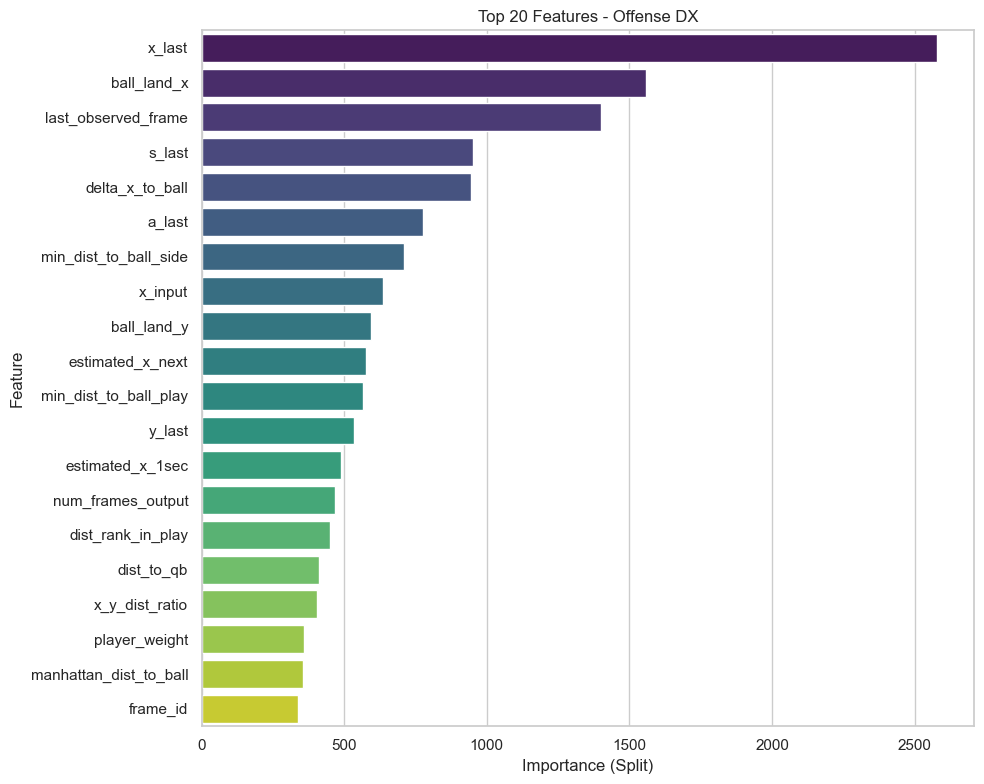

/var/folders/gq/d76lmnf57776ty42h5bk0f080000gn/T/ipykernel_91776/1103504206.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




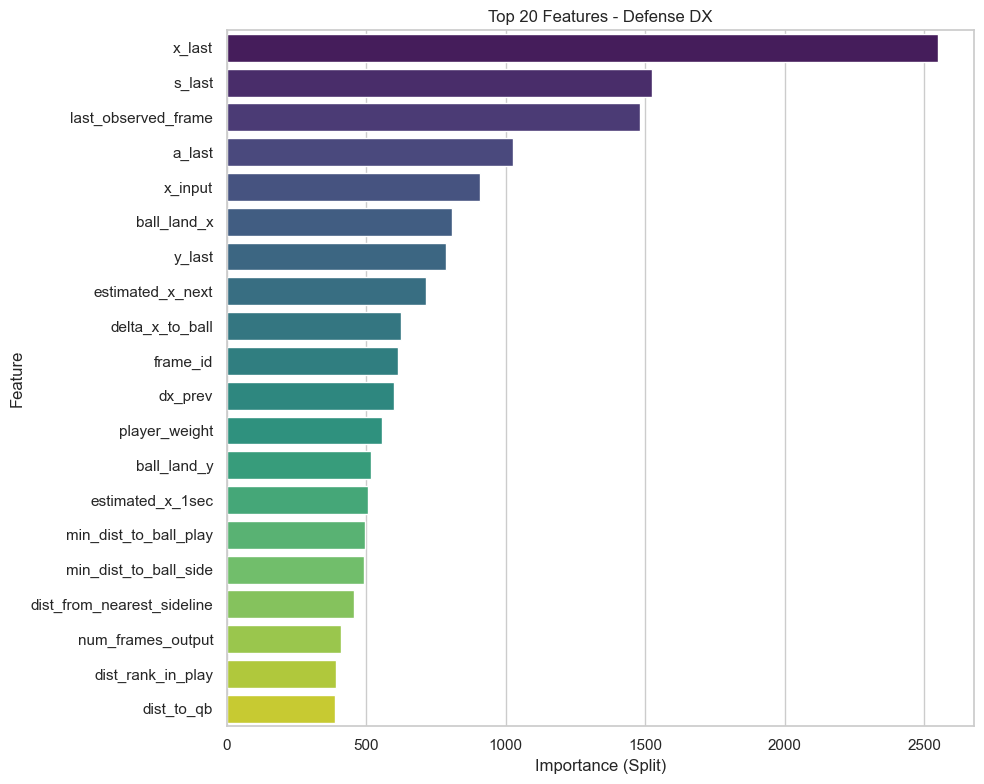

/var/folders/gq/d76lmnf57776ty42h5bk0f080000gn/T/ipykernel_91776/1103504206.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




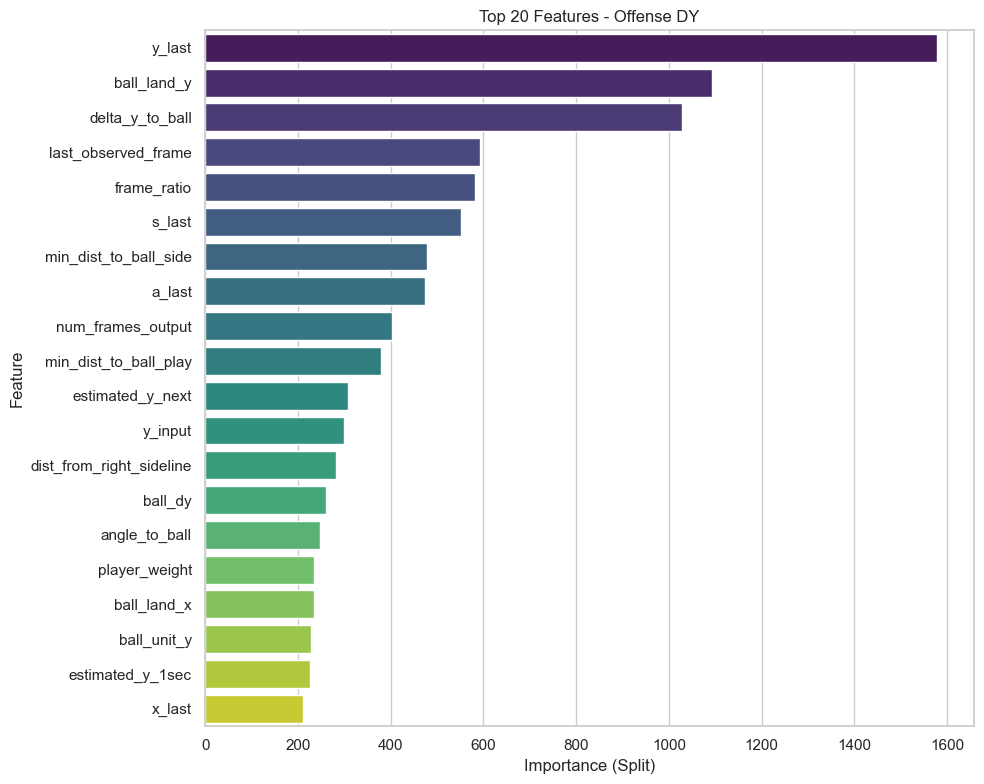

/var/folders/gq/d76lmnf57776ty42h5bk0f080000gn/T/ipykernel_91776/1103504206.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




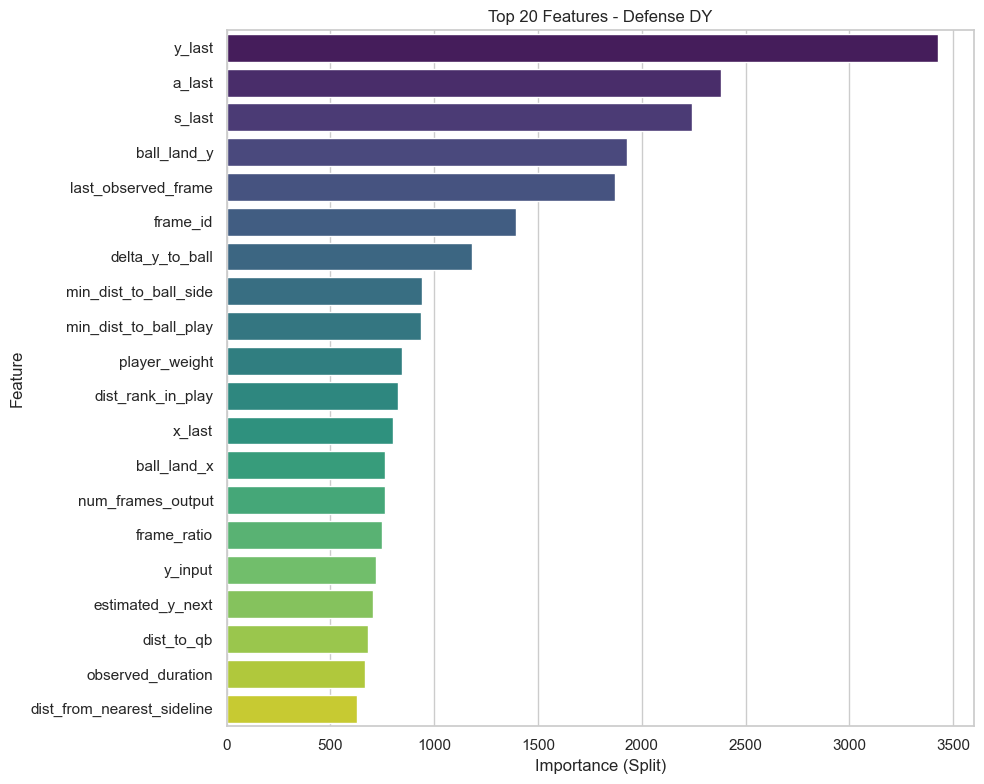

In [32]:
def plot_feature_importance(model, feature_names, top_n=20, title="Feature Importance"):
    importance = model.feature_importances_
    df_imp = pd.DataFrame({'feature': feature_names, 'importance': importance})
    df_imp = df_imp.sort_values('importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis')
    plt.title(title)
    plt.xlabel("Importance (Split)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Plot importance for Offense DX
plot_feature_importance(lgb_dx_off, feature_cols, title="Top 20 Features - Offense DX")
plot_feature_importance(lgb_dx_def, feature_cols, title="Top 20 Features - Defense DX")
plot_feature_importance(lgb_dy_off, feature_cols, title="Top 20 Features - Offense DY")
plot_feature_importance(lgb_dy_def, feature_cols, title="Top 20 Features - Defense DY")

# One tree of LGBM (Offense DX)

In [ ]:
# 1. Setup the plot size (Make it large so text is readable)
plt.figure(figsize=(24, 14), dpi=150)

# 2. Plot the tree
# tree_index=0: Plots the very first tree in the ensemble
# show_info: Shows 'split_gain' (importance) and 'internal_value' (prediction at that node)
ax = lgb.plot_tree(
    lgb_dx_off, 
    tree_index=0, 
    figsize=(24, 14), 
    show_info=['split_gain', 'internal_value'],
    precision=2
)

plt.title("LightGBM Decision Tree #0 (Offense DX)", fontsize=20)
plt.show()

# Submission

In [ ]:
# %% [markdown]
# ## 9. Submission (Robust Version)

import traceback

EVAL_DIR = DATA_DIR / 'kaggle_evaluation'
if str(EVAL_DIR) not in sys.path:
    sys.path.append(str(EVAL_DIR))

import kaggle_evaluation.nfl_inference_server

FIELD_LENGTH = 120.0
FIELD_WIDTH = 53.3

def predict(test: pl.DataFrame, test_input: pl.DataFrame) -> pd.DataFrame:
    try:
        # 0) Convert Polars -> Pandas
        base = test.to_pandas()
        df = test_input.to_pandas()

        # 1) Keep only players to predict
        df = df[df['player_to_predict'] == True].copy()

        # 2) Track original left plays to invert later
        was_left = df['play_direction'].astype(str).str.lower().eq('left')

        # 3) Engineer Features
        df = engineer_features(df)
        
        # Ensure alignment
        df['x_input'] = df['x']
        df['y_input'] = df['y']

        # 4) Feature Matrix - Ensure all cols exist
        # (Fill missing columns with 0 to prevent errors if feature engineering varies)
        for col in feature_cols:
            if col not in df.columns:
                df[col] = 0
        
        X_api = df[feature_cols].fillna(0)

        # 5) Predict
        preds_dx = np.zeros(len(X_api), dtype=float)
        preds_dy = np.zeros(len(X_api), dtype=float)

        off_mask = (df['is_offense'] == 1).values
        def_mask = ~off_mask

        if off_mask.any():
            preds_dx[off_mask] = lgb_dx_off.predict(X_api[off_mask])
            preds_dy[off_mask] = lgb_dy_off.predict(X_api[off_mask])

        if def_mask.any():
            preds_dx[def_mask] = lgb_dx_def.predict(X_api[def_mask])
            preds_dy[def_mask] = lgb_dy_def.predict(X_api[def_mask])

        # 6) Absolute positions (Mirrored Frame)
        x_pred = df['x_input'].values + preds_dx
        y_pred = df['y_input'].values + preds_dy

        # 7) Invert back to original field orientation
        left_idx = was_left.values
        x_pred[left_idx] = FIELD_LENGTH - x_pred[left_idx]
        y_pred[left_idx] = FIELD_WIDTH - y_pred[left_idx]

        # 8) Merge back
        pred_df = df[['game_id', 'play_id', 'nfl_id', 'frame_id']].copy()
        pred_df['x'] = x_pred
        pred_df['y'] = y_pred

        out = base.merge(
            pred_df,
            on=['game_id', 'play_id', 'nfl_id', 'frame_id'],
            how='left'
        )[['x', 'y']].fillna(0)

        return out

    except Exception as e:
        # SAFETY NET: Log error and return dummy zeros to prevent Submission Error
        print(f"ERROR in predict: {e}")
        traceback.print_exc()
        return pd.DataFrame({'x': [0.0]*len(base), 'y': [0.0]*len(base)})

# --- Server Start ---
inference_server = kaggle_evaluation.nfl_inference_server.NFLInferenceServer(predict)

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    inference_server.serve()
else:
    print("Ready for submission via specific gateway.")